In [1]:
%pylab inline
import os,sys,pickle,yaml
from builtins import sum as bsum
from importlib import reload
plt.style.use('default')
os.environ["FISHER_PLUMES"] = os.path.join(os.environ["GIT"],"fisher-plumes")
os.chdir(os.environ["FISHER_PLUMES"])



Populating the interactive namespace from numpy and matplotlib


In [2]:
try:
    UNITS
except NameError:
    import units; reload(units); UNITS = units.UNITS;


In [24]:
import boulder;   reload(boulder)
import crick;     reload(crick)
import fisher_plumes_tools as fpt;      reload(fpt)
import fisher_plumes as fp;             reload(fp)
import proc; reload(proc);
import assumptions as assm;



INFO:boulder:Boulder simulation data available for:


INFO:boulder:Re100_0_5mm_50Hz_16source_manuscript.h5         : ['Odor Data/c1a', 'Odor Data/c1b', 'Odor Data/c2a', 'Odor Data/c2b', 'Odor Data/c3a', 'Odor Data/c3b', 'Odor Data/c4a', 'Odor Data/c4b', 'Odor Data/c5a', 'Odor Data/c5b', 'Odor Data/c6a', 'Odor Data/c6b', 'Odor Data/c7a', 'Odor Data/c7b', 'Odor Data/c8a', 'Odor Data/c8b'] (16 datasets)


INFO:boulder:Re100_0_5mm_50Hz_pi4SourceSep.h5                : ['Odor Data/c1a', 'Odor Data/c2a', 'Odor Data/c3a', 'Odor Data/c4a', 'Odor Data/c5a', 'Odor Data/c6a', 'Odor Data/c7a', 'Odor Data/c8a', 'Odor Data/c9a', 'Odor Data/c10a', 'Odor Data/c11a', 'Odor Data/c12a', 'Odor Data/c13a', 'Odor Data/c14a', 'Odor Data/c15a', 'Odor Data/c16a'] (16 datasets)


INFO:boulder:Re100_0_5mm_50Hz_streamwiseSourceSep.h5         : ['Odor Data/c1a', 'Odor Data/c2a', 'Odor Data/c3a', 'Odor Data/c4a', 'Odor Data/c5a', 'Odor Data/c6a', 'Odor Data/c7a', 'Odor Data/c8a', 'Odor Data/c9a', 'Odor Data/c10a', 'Odor Data/c11a', 'Odor Data/c12a', 'Odor Data/c13a', 'Odor Data/c14a', 'Odor Data/c15a', 'Odor Data/c16a'] (16 datasets)


INFO:crick:Simulation data available for:


...

INFO:crick:n12dishT                                        : Y0.450 - Y0.550 (11 datasets)


INFO:crick:n16T                                            : Y0.440 - Y0.560 (16 datasets)


INFO:crick:n16Tslow                                        : Y0.440 - Y0.560 (16 datasets)


INFO:crick:n16Tslow_45deg                                  : X0.418Y0.458 - X0.502Y0.542 (16 datasets)


INFO:crick:n16Tslow_X                                      : X0.400 - X0.648 (32 datasets)


In [4]:
results = proc.find_registry_matches(init_filter={"sim_name":"boulder16", "which_coords":(0.45, 0.5) * UNITS.m}, compute_filter={"window_shape":"hann", "window_length":1 * UNITS.s})
print(len(results))

                    proc 2024/07/28 09:22:37     INFO: No registry given. Loading registry from proc/registry.p.


                    proc 2024/07/28 09:22:37     INFO: Checking for x_m=0.45, y_m=0.5.


1


In [5]:
init_filter = {"sim_name": "boulder16", "which_coords":(0.45, 0.5) * UNITS.m}
compute_filter = {"window_shape": "hann", "window_length": 1 * UNITS.s, "fit_k":False, "fit_b":True, "dmax_um": "1 * PITCH"}
results = proc.load_data(init_filter, compute_filter, fit_corrs = [], strict = True)

                    proc 2024/07/28 09:22:38     INFO: Checking for x_m=0.45, y_m=0.5.


                    proc 2024/07/28 09:22:38     INFO: Loading init_filter={'sim_name': 'boulder16', 'which_coords': <Quantity([0.45 0.5 ], 'meter')>} compute_filter={'window_shape': 'hann', 'window_length': <Quantity(1, 'second')>, 'fit_k': False, 'fit_b': True, 'dmax_um': '1 * PITCH'} from proc/bw.1/72796384e420d8ea.p, last modified 2024-07-11 19:36:36.


                    proc 2024/07/28 09:22:40     INFO: Returning 1 results.


In [6]:
[p.logger.setLevel(logging.WARN) for p in [boulder, crick, fp]]
F = fp.FisherPlumes(results[0])
[p.logger.setLevel(logging.INFO) for p in [boulder, crick, fp]];

In [7]:
from assumptions import Energy

# Are the distributions the same from each source?

In [8]:
n = 4
src1 = 5
src2 = 8
estat = []
for n in range(26):
    a = F.cc[0][src1][0,:,n]
    b = F.ss[0][src1][0,:,n]
    c = F.cc[0][src2][0,:,n]
    d = F.ss[0][src2][0,:,n]
    X = np.array([a,b]).T
    Y = np.array([c,d]).T
    estat.append(Energy.test(X,Y,1000))
    print(n, estat[-1])

0 0.159


1 0.83


2 0.813


3 0.7


KeyboardInterrupt: 

In [13]:
yaml_file = "test_assm_loc_ind.yaml"
with open(yaml_file, 'r') as f:
    contents = yaml.safe_load(f)
print(contents)

{'location_independence': {'run': True, 'seed': 0, 'n_perm': 1000, 'iprb': 0}}


In [30]:
ifreq = 10
iprb = contents["location_independence"]["iprb"]
ss = F.ss[iprb]
cc = F.cc[iprb]
srcs = sorted(list(ss.keys()))
results = []
for i1, s1 in enumerate(srcs):
    for i2 in range(i1, len(srcs)):
        s2 = srcs[i2]
        a = cc[s1][0,:,ifreq]
        b = ss[s1][0,:,ifreq]
        c = cc[s2][0,:,ifreq]
        d = ss[s2][0,:,ifreq]
        X = np.array([a,b]).T
        Y = np.array([c,d]).T
        estat = Energy.test(X,Y,contents["location_independence"]["n_perm"])
        results.append((i1, i2, s1, s2, ifreq, estat))
        print(results[-1])

(0, 0, 0, 0, 10, 1.0)


(0, 1, 0, 1, 10, 0.997)


(0, 2, 0, 2, 10, 0.965)


(0, 3, 0, 3, 10, 0.991)


(0, 4, 0, 4, 10, 0.762)


...

(13, 14, 13, 14, 10, 1.0)


(13, 15, 13, 15, 10, 0.981)


(14, 14, 14, 14, 10, 1.0)


(14, 15, 14, 15, 10, 1.0)


(15, 15, 15, 15, 10, 1.0)


16


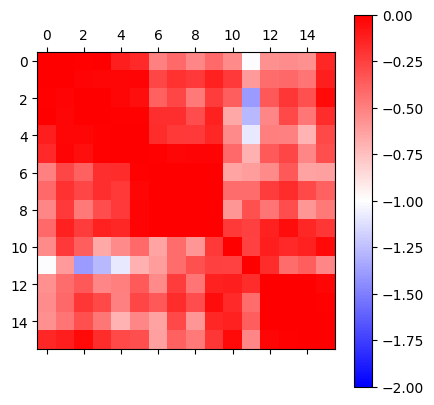

In [59]:
matshow(squareform(log10(r)), vmin=-2, vmax=0,cmap='bwr'); colorbar()

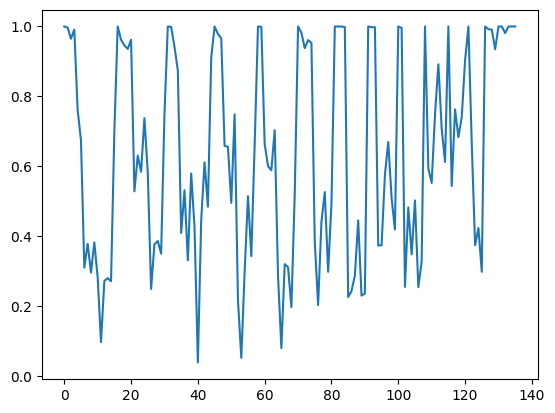

In [32]:
R = np.array(results)
r = R[:,-1]
plot(r)

In [26]:
reload(assm)

NameError: name 'assm' is not defined

In [27]:
import assumptions as assm
reload(assm)

<module 'assumptions' from '/nemo/lab/schaefera/working/tootoos/git/fisher-plumes/assumptions.py'>

In [28]:
data_file = "proc/bw.1/test_assm/test_assm_loc_ind/3238b8e00bad74f9.p"
results = pickle.load(open(data_file, 'rb'))

<ipython-input-63-885685fcc2b0>:3: RuntimeWarning: divide by zero encountered in log10
  matshow(log10(vec), cmap='gnuplot_r'); colorbar()


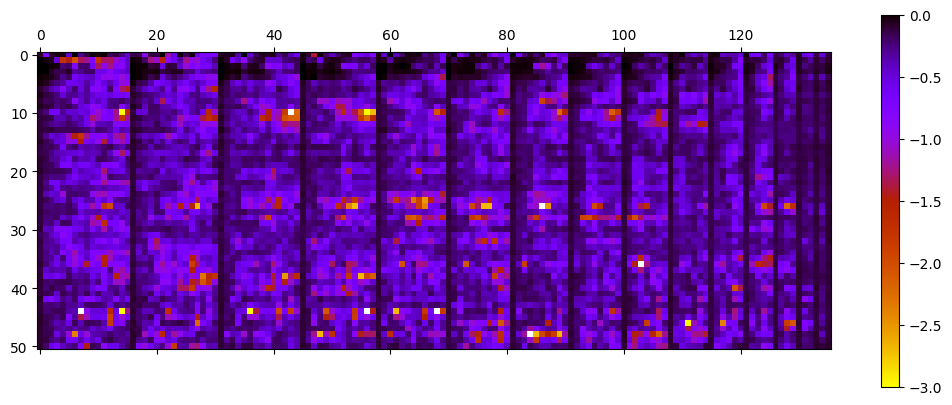

In [63]:
reload(assm)
vec,ifreqs,keys = assm.LocationIndependence.results_to_vec(results["results"]["location_independence"])
matshow(log10(vec), cmap='gnuplot_r'); colorbar()

# Checking temporal stationarity

### Are the distributions of sine and cosine coefficients the same?

In [199]:
import assumptions as A

In [201]:
len(a)

119

In [207]:
# Let's
n = 4
src1 = 3
a = F.cc[0][src1][0,:,n].reshape(-1,1)
b = F.ss[0][src1][0,:,n].reshape(-1,1)
A.Energy.test(a,b)


0.39

In [218]:
c = [np.sum(F.cc[0][src1][i,:,n] * F.ss[0][src1][i,:,n]) for i in range(0,51)]

In [220]:
c = [np.sum(F.cc[0][s][0,:,n] * F.ss[0][s][0,:,n]) for s in range(16)]

In [225]:
stats.wilcoxon(c)

WilcoxonResult(statistic=63.0, pvalue=0.820892333984375)

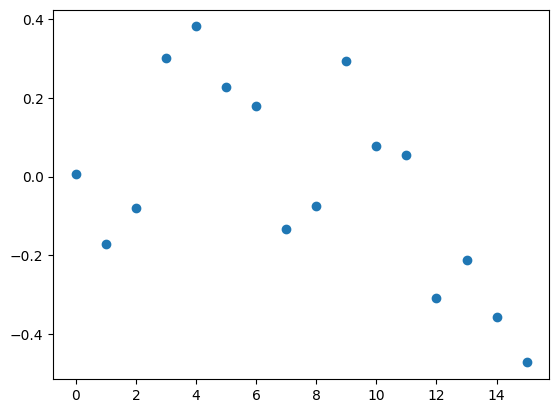

In [223]:
plot(c, "o")

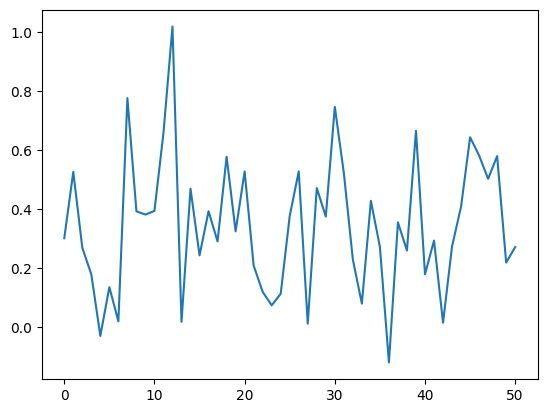

In [219]:
plot(c)

In [212]:
# Import ttest
import scipy.stats as stats

In [214]:
stats.wilcoxon(b)

WilcoxonResult(statistic=array([3235.]), pvalue=array([0.37434892]))

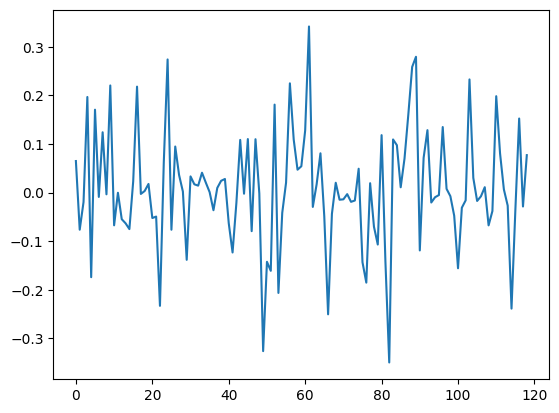

In [208]:
plot(a)

In [203]:
len(a)

119

In [103]:
reload(assm)
data_file = "proc/bw.1/test_assm/test_assm_stationarity/3238b8e00bad74f9.p"
results = pickle.load(open(data_file, 'rb'))

In [104]:
res = results["results"]["stationarity"]

In [105]:
ifreqs = [k.ifreq for k in res.keys()]

In [109]:
reload(assm)
vec,ifreqs,keys = assm.Stationarity.results_to_vec(results["results"]["stationarity"])
vec.shape#matshow(log10(vec), cmap='gnuplot_r'); colorbar()


(51, 16, 4)

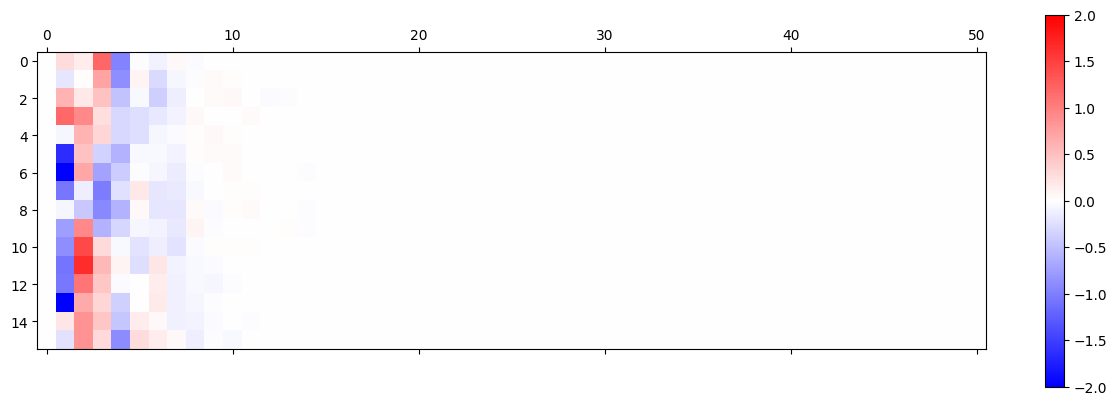

In [117]:
matshow(vec[:,:,-1].T, cmap='bwr',vmin=-2,vmax=2); colorbar()

In [124]:
wilcoxon(zeros(10,)+1e-8)

WilcoxonResult(statistic=0.0, pvalue=0.001953125)

In [125]:
wc_test = lambda x: 1 if np.allclose(x,0) else wilcoxon(x).pvalue
wc = [wc_test(vec[i,:,-1].flatten()) for i in range(vec.shape[0])]


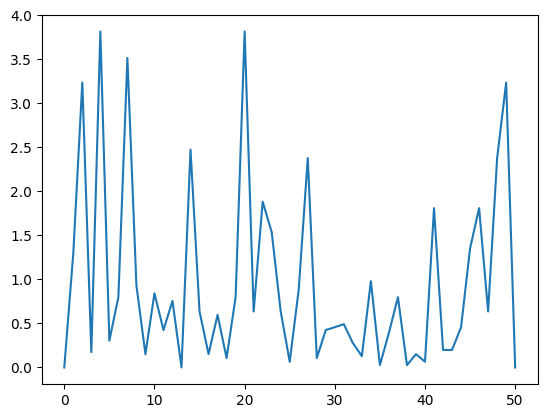

In [128]:
plot(-log10(wc))

<ipython-input-129-6a651181f330>:1: RuntimeWarning: divide by zero encountered in log10
  matshow(-log10(vec[:,:,0]).T, cmap='gnuplot'); colorbar()


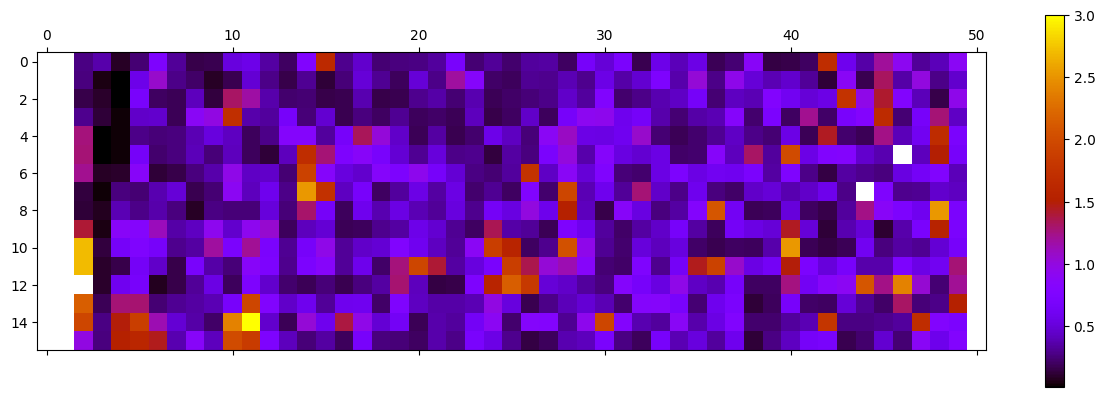

In [129]:
matshow(-log10(vec[:,:,0]).T, cmap='gnuplot'); colorbar()

In [83]:
vec.shape

(40, 16, 4)

# Checking whether joint distributions only depend on the distance between sources.

In [15]:
# Get the fp_data file that we want to plot
matches = proc.find_registry_matches(init_filter = {"sim_name":"boulder16", "which_coords":(0.45, 0.5) * UNITS.m},
                                     compute_filter = {"window_shape":"hann", "window_length": 1 * UNITS.s, "dmax_um":"1 * PITCH"})

                    proc 2024/07/28 09:27:15     INFO: No registry given. Loading registry from proc/registry.p.


                    proc 2024/07/28 09:27:15     INFO: Checking for x_m=0.45, y_m=0.5.


In [39]:
full_file_name = matches[0]["file"]
fp_data = pickle.load(open(full_file_name, 'rb'))["results"]
suffix = full_file_name.split("/")[-1]
print(full_file_name, suffix)

proc/bw.1/72796384e420d8ea.p 72796384e420d8ea.p


In [57]:
reload(boulder); reload(fp)
[x.logger.setLevel(logging.WARN) for x in [boulder, fp]]
F = fp.FisherPlumes(fp_data)

In [62]:
data_file = "proc/bw.1/test_assm/test_assm_joint_dist/" + suffix
results = pickle.load(open(data_file, 'rb'))


In [121]:
import fisher_plumes_figs as fpf

In [123]:
fpf.pitch_sym

'$\\phi$'

0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3, 3.3, 3.6, 3.9, 4.2, [0. 1. 2. 3.]


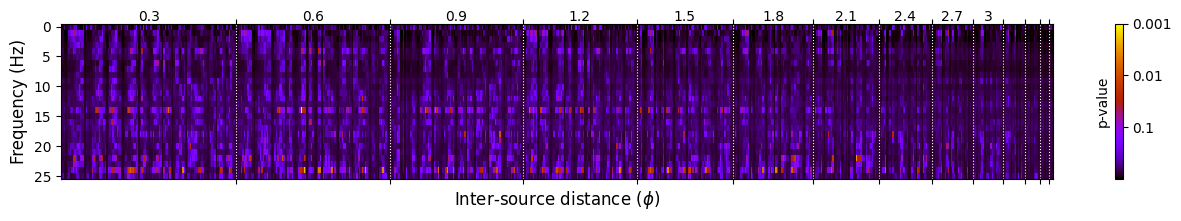

In [164]:
vec,ifreqs,keys = assm.JointDist.results_to_vec(results["results"]["joint_dist"])
dists = np.array([k.dist for k in keys[0]])
assert list(dists) == sorted(dists)
unique_dists = sorted(np.unique(dists))
vals = vec.reshape((-1, len(dists)))
vals[vals == 0] = np.nan
matshow(-log10(vals), cmap='gnuplot');
axis('auto')
yt = gca().get_yticks()
valid_yt = [int(yti) for yti in yt if yti in ifreqs]
freqs = F.inds2freqs(valid_yt)
yticks(valid_yt, [f"{f.to(UNITS.Hz).magnitude:g}" for f in freqs])
ylabel("Frequency (Hz)", fontsize=12)
# Each column is a pair of sources being compared.
# These will be in blocks sorted by the distance between the sources.
# So e.g. the first N_1 columns will be at the  minimum distance, the next N_2 columns will be at the next largest distance, etc.
# I want major ticks to be at the start of each block.
xt_loc = np.where(np.diff(dists) > 0)[0] + 0.5
# I don't want the major ticks to be labeld, so I'll set the labels to empty strings.
xt_loc1 = np.array([0] + list(xt_loc) + [len(dists)])
midpoints = (xt_loc1[1:] + xt_loc1[:-1]) / 2
xticks(xt_loc, [""]*len(xt_loc))
for i, mid in enumerate(midpoints):
    dist_um = unique_dists[i]
    dist_pitch = (dist_um * UNITS.um).to(F.pitch).magnitude
    print(f"{dist_pitch:g}", end = ", ")
    (dist_pitch < 3.1) and text(mid, -1, f"{dist_pitch:g}", ha='center', fontsize=10 if dist_pitch <= 3.4 else 6)
xlabel(f"Inter-source distance ({fpf.pitch_sym})", fontsize=12)
# Turn the grid on, but only for the x-ticks, and using a dotted line.
grid(axis='x', linestyle=':', color='w')

cax = colorbar().ax
yt = cax.get_yticks()
print(yt)
cax.set_yticklabels([f"{10**-yti:g}" for yti in yt])
cax.set_ylabel("p-value")
# Set the position of the label to the left of the colorbar
cax.yaxis.set_label_position('left')
savefig("figs/joint_dist.png", dpi=300, bbox_inches='tight')

# Checking whether the distribution of coefficients is Gaussian

In [144]:
def test_gaussian(X, n_rand = None):
    if n_rand is None:
        n_rand = len(X)

    Xm = np.mean(X, axis=0)
    Xcov = np.cov(X.T)
    Y = np.random.multivariate_normal(Xm, Xcov, n_rand)
    return fpt.Energy.test(X,Y,1000)

In [169]:
n    = 10
src1 = 5
src2 = 8
a = F.cc[0][src1][0,:,n]
b = F.ss[0][src1][0,:,n]
X = np.array([a,b]).T
print(test_gaussian(X))

0.0


In [69]:
reload(assm)
data_file = "proc/bw.1/test_assm/test_assm_gauss_coefs/3238b8e00bad74f9.p"
results = pickle.load(open(data_file, 'rb'))

Text(0, 0.5, 'Source Index')

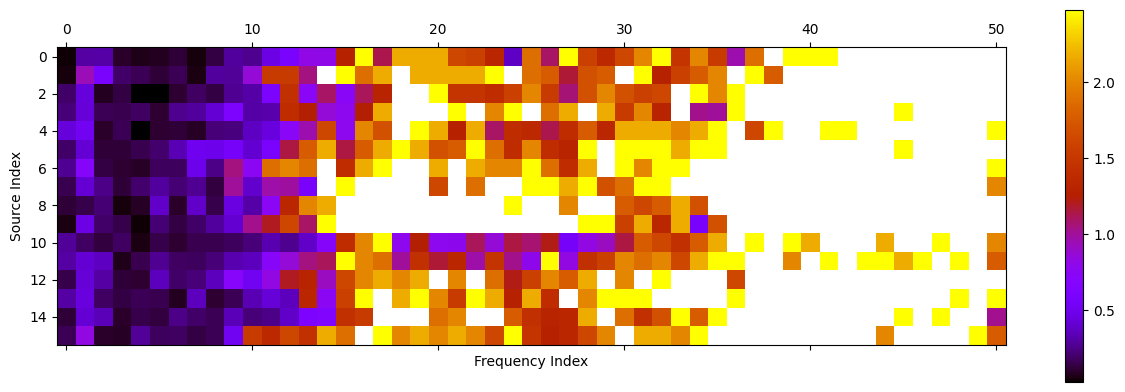

In [77]:
vec,ifreqs,keys = assm.GaussianCoefs.results_to_vec(results["results"]["gaussian_coefs"])
vec[vec==0] = nan
matshow(-log10(vec).T, cmap='gnuplot'); colorbar()
xlabel("Frequency Index")
ylabel("Source Index")


# Checking whether the conditional distribution of coefficients is Gaussian

In [167]:
# Get the fp_data file that we want to plot
matches = proc.find_registry_matches(init_filter = {"sim_name":"boulder16", "which_coords":(0.45, 0.5) * UNITS.m},
                                     compute_filter = {"window_shape":"hann", "window_length": 1 * UNITS.s, "dmax_um":"1 * PITCH"})
full_file_name = matches[0]["file"]
fp_data = pickle.load(open(full_file_name, 'rb'))["results"]
suffix = full_file_name.split("/")[-1]
print(full_file_name, suffix)




                    proc 2024/07/28 13:48:54     INFO: No registry given. Loading registry from proc/registry.p.


                    proc 2024/07/28 13:48:54     INFO: Checking for x_m=0.45, y_m=0.5.


proc/bw.1/72796384e420d8ea.p 72796384e420d8ea.p


In [286]:
reload(boulder); reload(fp)
reload(assm)
[x.logger.setLevel(logging.WARN) for x in [boulder, fp]]
F = fp.FisherPlumes(fp_data)

data_file = "proc/bw.1/test_assm/test_assm_cond_gauss/" + suffix
results = pickle.load(open(data_file, 'rb'))
spec = utils.load_yaml(results["test_assm_spec"])
vec,ifreqs,keys,bad_keys = assm.ConditionalGaussian.results_to_vec(results["results"]["cond_gauss"], n_bins = spec["cond_gauss"]["n_bins"],n_trials = spec["cond_gauss"]["n_trials"], min_count_per_bin = 10)


             assumptions 2024/07/28 15:26:29     INFO: Nan'd 136 keys due to missing or incomplete data.


In [298]:
vec_m = np.nanmean(np.nanmean(vec, axis=-1),axis=-1);

<ipython-input-298-15162faecd5f>:1: RuntimeWarning: Mean of empty slice
  vec_m = np.nanmean(np.nanmean(vec, axis=-1),axis=-1);


[0. 1. 2. 3.]


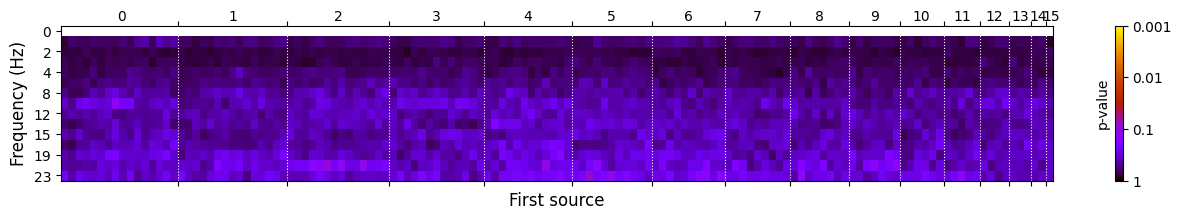

In [329]:
matshow(-log10(vec_m), vmin=0, vmax=3, cmap='gnuplot');
axis("auto")
src1 = np.array([k.src1 for k in keys[0]])
assert list(src1) == sorted(src1)
unique_src1 = sorted(np.unique(src1))
axis('auto')

xt_loc = np.where(np.diff(src1) > 0)[0] + 0.5
# I don't want the major ticks to be labeld, so I'll set the labels to empty strings.
xt_loc1 = np.array([0] + list(xt_loc) + [len(src1)])
midpoints = (xt_loc1[1:] + xt_loc1[:-1]) / 2
xticks(xt_loc, [""]*len(xt_loc))
for i, mid in enumerate(midpoints):
    text(mid, -1, f"{unique_src1[i]:g}", ha='center', fontsize=10)
xlabel(f"Conditioning source", fontsize=12)
# Turn the grid on, but only for the x-ticks, and using a dotted line.
grid(axis='x', linestyle=':', color='w')

yt = gca().get_yticks()
yt = yt[(0 <= yt)* (yt< len(ifreqs))]
yt_freqs = [f"{f.to(UNITS.Hz).magnitude:g}" for f in F.inds2freqs(np.array(ifreqs)[yt.astype(int)])]
yticks(yt, yt_freqs)
ylabel("Frequency (Hz)", fontsize=12)

cax = colorbar().ax
yt = cax.get_yticks()
print(yt)
cax.set_yticklabels([f"{10**-yti:g}" for yti in yt])
cax.set_ylabel("p-value")
# Set the position of the label to the left of the colorbar
cax.yaxis.set_label_position('left')
savefig("figs/cond_gauss.png", dpi=300, bbox_inches='tight')


# Test temporal stationarity

In [158]:
x = np.array(["ab","cd","ef"])# 1. p(a_n=v) = p(b_n=v)


In [159]:
x == "ab"

array([ True, False, False])

In [160]:
set(x)


{'ab', 'cd', 'ef'}

In [161]:
from collections import Counter

In [162]:
Counter(x)

Counter({'ab': 1, 'cd': 1, 'ef': 1})